In [186]:
import pandas as pd
import numpy as np
import csv 

from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('simpsons.csv')
df.head()

,Unnamed: 0,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31.0
1,1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3.0
2,2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22.0
3,3,9552,32,212,Lisa Simpson: That life is worth living.,864000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,That life is worth living.,that life is worth living,5.0
4,4,9553,32,213,Edna Krabappel-Flanders: The polls will be ope...,864000,True,40.0,3.0,Edna Krabappel-Flanders,Springfield Elementary School,The polls will be open from now until the end ...,the polls will be open from now until the end ...,33.0


In [4]:
# file_name = 'simpsons_script_lines.csv'

# with open(file_name, 'r') as f:  
#     df = pd.DataFrame(columns = next(f).strip().split(','))
#     csv_file = csv.reader(f) 
#     for row in csv_file: 
#         df.loc[len(df)] = row

# df.head()

# Word2Vec

In [6]:
phrases = [text.split() for text in df['normalized_text'].fillna('')]
phrases[0]

['no',
 'actually',
 'it',
 'was',
 'a',
 'little',
 'of',
 'both',
 'sometimes',
 'when',
 'a',
 'disease',
 'is',
 'in',
 'all',
 'the',
 'magazines',
 'and',
 'all',
 'the',
 'news',
 'shows',
 'its',
 'only',
 'natural',
 'that',
 'you',
 'think',
 'you',
 'have',
 'it']

In [7]:
model = Word2Vec()
model.build_vocab(phrases, update=False)
model.train(phrases, total_examples=model.corpus_count, epochs=30, report_delay=1)

(28675491, 39195090)

# Visualization

In [11]:
def visualization(embeddings, words):
    tsne = TSNE(n_components=2, perplexity=len(words)-1)
    embedding = np.array([embeddings[word] for word in words])
    results = tsne.fit_transform(embedding)

    plt.figure(figsize=(20, 12))
    for i, word in enumerate(words):
        x, y = results[i, :]
        plt.scatter(x, y)
        plt.annotate(word, (x, y), xytext=(5, 2), textcoords="offset points", ha="right", va="bottom", alpha=0.7, size=9)
    plt.show()

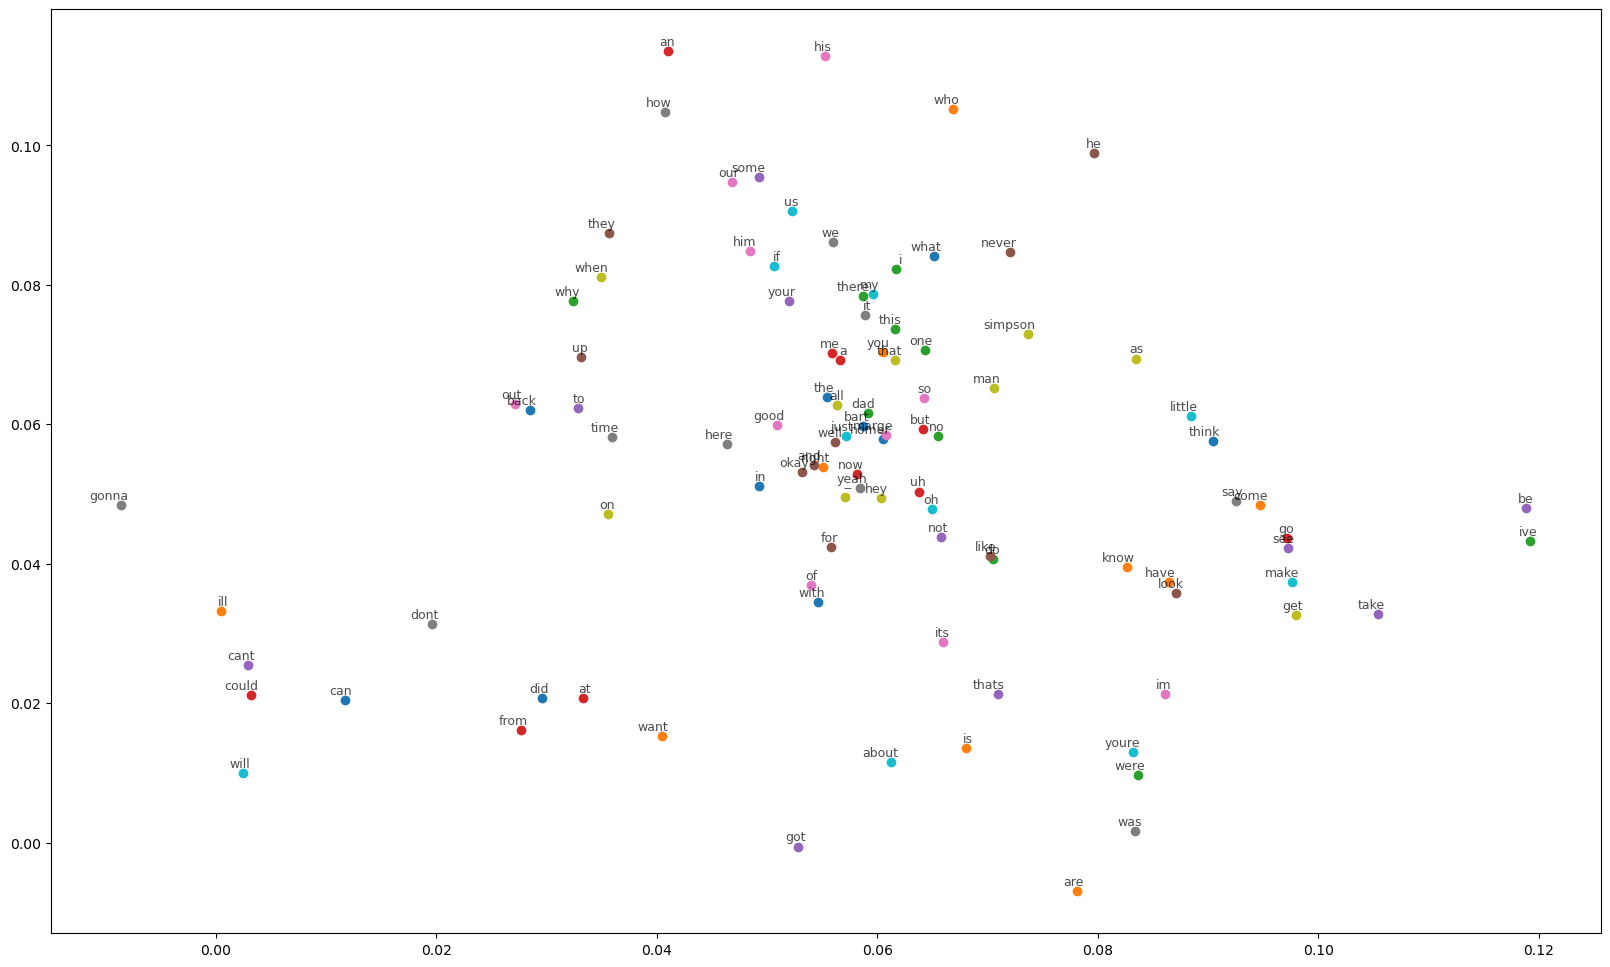

In [12]:
visualization(model.wv, model.wv.index_to_key[:100])

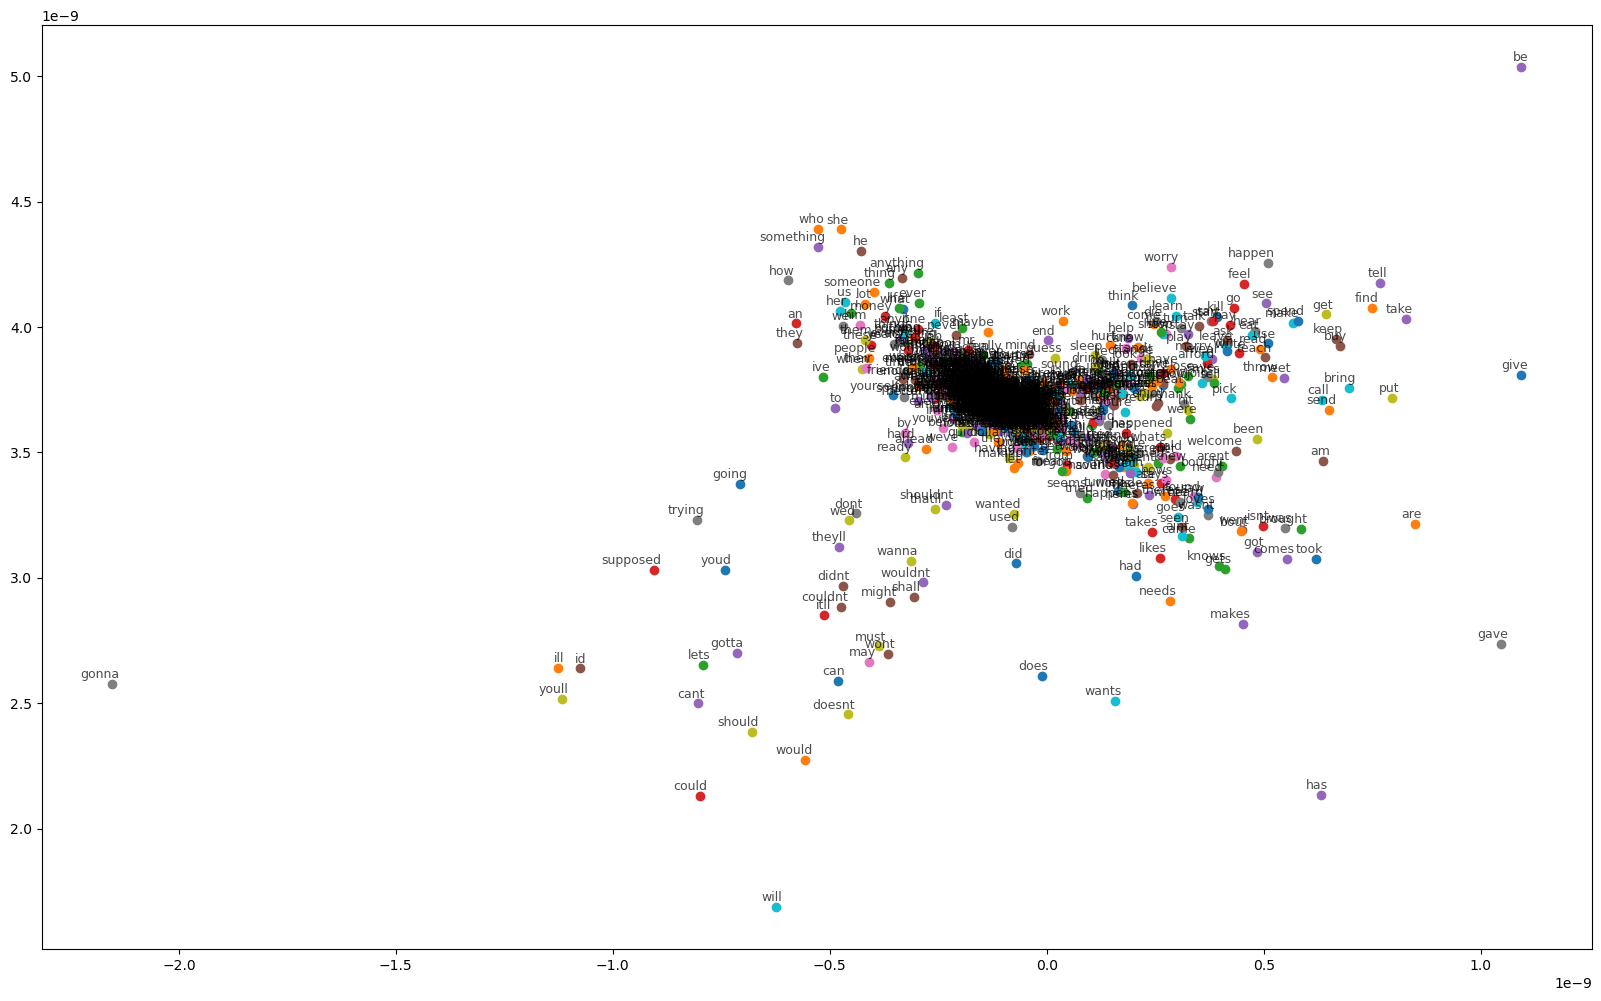

In [13]:
visualization(model.wv, model.wv.index_to_key[:1000])

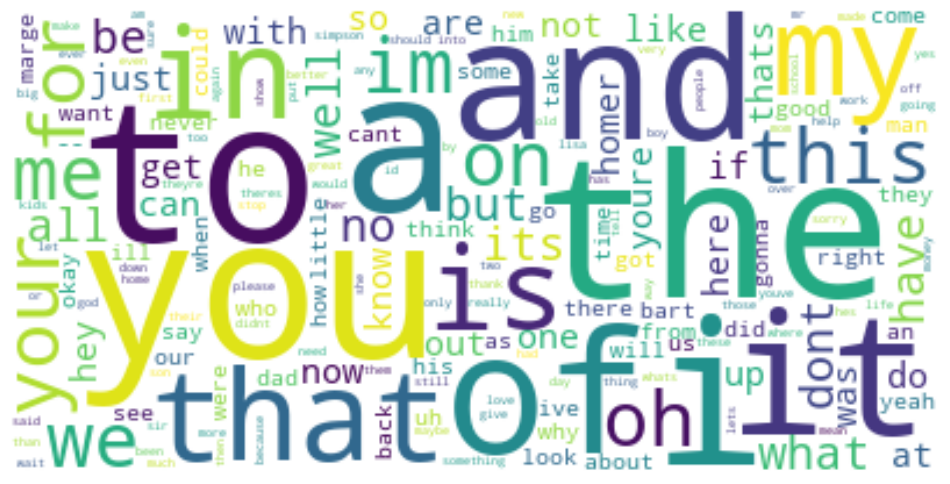

In [14]:
most_most_similar = {k:1000-v for k,v in list(model.wv.key_to_index.items())[:1000]}
wd = WordCloud(background_color = 'white', max_words=1000)
wd.generate_from_frequencies(most_most_similar)

plt.figure(figsize=(12, 8))
plt.imshow(wd, interpolation = 'bilinear')
plt.axis('off')
plt.show()

# Most Similar

In [8]:
model.wv.most_similar(positive=['homer','bart'], negative=['marge'])

[('grampa', 0.5832825899124146),
 ('dad', 0.570930004119873),
 ('son', 0.5504389405250549),
 ('lisa', 0.4998490810394287),
 ('milhouse', 0.49466177821159363),
 ('father', 0.4742238521575928),
 ('mom', 0.4586372673511505),
 ('boy', 0.42350706458091736),
 ('mrs', 0.4185248911380768),
 ('ralph', 0.4182126820087433)]

In [15]:
model.wv.most_similar(positive=['bart','school'], negative=['lisa'])

[('church', 0.5183139443397522),
 ('class', 0.45393556356430054),
 ('job', 0.44733545184135437),
 ('dad', 0.43819645047187805),
 ('hospital', 0.4235321283340454),
 ('kid', 0.410411536693573),
 ('work', 0.4096154272556305),
 ('store', 0.393867552280426),
 ('test', 0.39325523376464844),
 ('plant', 0.3911978006362915)]

In [16]:
model.wv.most_similar(positive=['marge','home'], negative=['homer'])

[('back', 0.5818283557891846),
 ('bed', 0.4056818187236786),
 ('sleep', 0.3914676606655121),
 ('grease', 0.39006394147872925),
 ('mad', 0.3856019079685211),
 ('visit', 0.38046085834503174),
 ('shack', 0.37550464272499084),
 ('out', 0.37379488348960876),
 ('hotel', 0.37041738629341125),
 ('here', 0.35902562737464905)]

# LogisticRegression

In [181]:
df_bart_lisa = df.loc[df['raw_character_text'].isin(['Lisa Simpson', 'Bart Simpson'])]
df_bart_lisa = df_bart_lisa[['raw_character_text', 'normalized_text']].dropna()
df_bart_lisa['raw_character_text'].value_counts()

raw_character_text
Bart Simpson    13014
Lisa Simpson    10770
Name: count, dtype: int64

In [182]:
X_train, X_test, y_train, y_test = train_test_split(df_bart_lisa['normalized_text'], df_bart_lisa['raw_character_text'], test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((19027,), (4757,))

In [183]:
def vectorize(model, sentence):
    words = sentence.split()
    words_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(words_vecs) == 0:
        return np.zeros(100)
    words_vecs = np.array(words_vecs)

    return words_vecs.mean(axis=0)

In [184]:
X_train_vector = np.array([vectorize(model, sentence) for sentence in X_train])
X_test_vector = np.array([vectorize(model, sentence) for sentence in X_test])

X_train_vector.shape, X_test_vector.shape

((19027, 100), (4757, 100))

In [187]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train_vector, y_train)

LogisticRegression(random_state=42)

In [188]:
y_pred = clf.predict(X_test_vector)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

Bart Simpson       0.62      0.75      0.68      2578
Lisa Simpson       0.60      0.45      0.52      2179

    accuracy                           0.61      4757
   macro avg       0.61      0.60      0.60      4757
weighted avg       0.61      0.61      0.60      4757

